# Calulate representativeness spatial field -- manually - 1

**The notebook helps you calculate the following:**
1. Calculate the nth order neighbouring grain list for target and sample grain structure grains.
2. Calculate the grsin sizes (metric: number of pixels) in target and sample grain structure.
3. Construct the target and sample field dictionary.
4. Calculate target and sample fields of: nneigh and npixels
5. Interpolate number of neighbors field onto the underlying target and sample grid and visualize.
6. Carry out O(n) sensitivity on the nneigh statistics.
7. Calculate the Kullback-Leiber divergence R-field for target1:target2

**The notebook helps you visualize the following:**
1. Plot the global target and sample grain structures
2. Plot the number of O(n) neighbours for target and sample at a given temporal slice.
3. Visualize the target's number of neighbours vs grain area (i.e. npixels) distributions in a seaborn jointplot.
4. Visualize all grains upto nth order neighbour of a given grain id.
5. Visualize all nth order neighbour grains of a given grain id.
6. Visualize the R field of the grain structure for a given a parent-subset dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from scipy.stats import entropy
from upxo.ggrowth.mcgs import mcgs
from upxo._sup import dataTypeHandlers as dth
from scipy.interpolate import griddata
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from upxo._sup.data_ops import find_outliers_iqr, distance_between_two_points

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
NUMBERS = dth.dt.NUMBERS
ITERABLES = dth.dt.ITERABLES
RNG = np.random.default_rng()

In [3]:
tgt = mcgs(study='independent', input_dashboard='mcgs2d_100x100_m50_q10_mcalg201.xls')
tgt.simulate()
tgt.detect_grains()
# =========================================================
smp = mcgs(study='independent', input_dashboard='mcgs2d_100x100_m50_q10_mcalg201.xls')
smp.simulate()
smp.detect_grains()

c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs
c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs\mcgs2d_100x100_m50_q10_mcalg201.xls
Algo_hops details
(('201.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 50.0, 1.0
     No. of states: 10
     Dimensionality: 2
     Algorithm: 201.0 





########################################
201.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 stored
 ..............................
GS temporal 

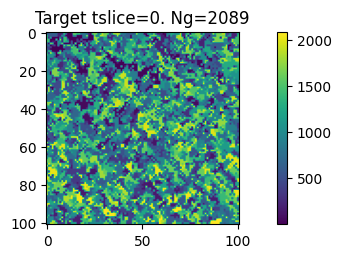

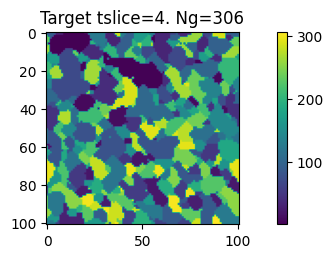

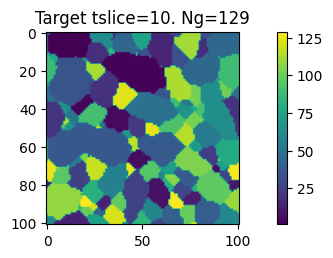

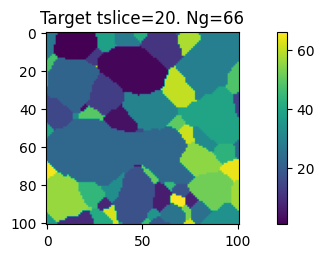

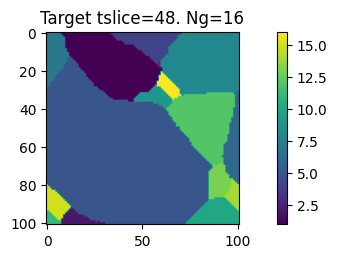

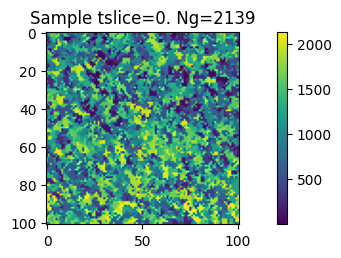

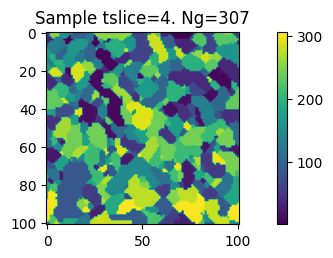

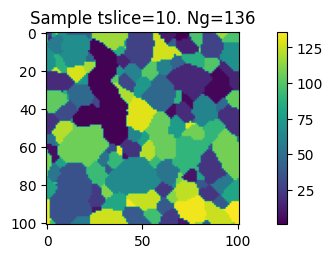

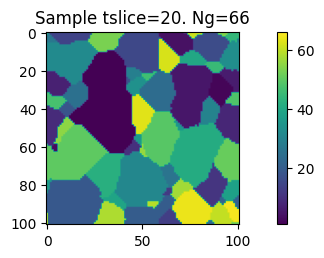

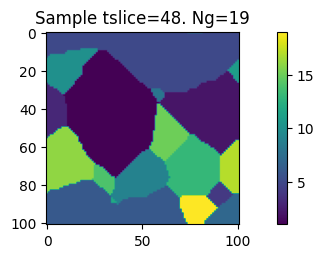

In [4]:
"""Plot the global target and sample grain structures"""
PLOT_TARGET_GS = True
if PLOT_TARGET_GS:
    _slices_to_plot_ = [0, 4, 10, 20, 48]
    for _s_ in _slices_to_plot_:
        plt.figure(figsize=(10, 2.5), dpi=100)
        plt.imshow(tgt.gs[_s_].lgi), plt.colorbar()
        plt.title(f'Target tslice={_s_}. Ng={tgt.gs[_s_].n}')

PLOT_SAMPLE_GS = True
if PLOT_SAMPLE_GS:
    _slices_to_plot_ = [0, 4, 10, 20, 48]
    for _s_ in _slices_to_plot_:
        plt.figure(figsize=(10, 2.5), dpi=100)
        plt.imshow(smp.gs[_s_].lgi), plt.colorbar()
        plt.title(f'Sample tslice={_s_}. Ng={smp.gs[_s_].n}')

In [5]:
tgt_slice = 2
smp_slice = 4

In [6]:
"""
Calculate the nth order neighbouring grain list for target and sample grain
structure grains.
"""
neigh_order = 1
tgt_nneighgids = tgt.gs[tgt_slice].get_upto_nth_order_neighbors_all_grains(neigh_order,
                                                                           include_parent=True,
                                                                           output_type='nparray')
smp_nneighgids = smp.gs[smp_slice].get_upto_nth_order_neighbors_all_grains(neigh_order,
                                                                           include_parent=True,
                                                                           output_type='nparray')


 -------------------------
NOTE:  
 	 This gs tslice has'nt been characterised.
NOTE:  
 	 Charecterising to proceed.
Extracting requested GS props across all available states
--------State value: 5 of 10
--------State value: 10 of 10
----------------------------------------
NOTE:  
 	 this gs tslice has now been charactised.
NOTE:  
 	 Proceeding with neighbourhood gid calculations.

 -------------------------
Extracting neigh list for grain: 100
Extracting neigh list for grain: 200
Extracting neigh list for grain: 300
Extracting neigh list for grain: 400
Extracting neigh list for grain: 500

 -------------------------
NOTE:  
 	 This gs tslice has'nt been characterised.
NOTE:  
 	 Charecterising to proceed.
Extracting requested GS props across all available states
--------State value: 5 of 10
--------State value: 10 of 10
----------------------------------------
NOTE:  
 	 this gs tslice has now been charactised.
NOTE:  
 	 Proceeding with neighbourhood gid calculations.

 ---------

In [7]:
"""
Calculate the grsin sizes (metric: number of pixels) in target and sample
grain structure.
"""
tgt_npixels = tgt.gs[tgt_slice].find_grain_size_fast(metric='npixels')
smp_npixels = smp.gs[smp_slice].find_grain_size_fast(metric='npixels')
tgt_npixels_mean = tgt_npixels.mean()
smp_npixels_mean = smp_npixels.mean()

**Construct the target and sample field dictionary with the following keys.**
- neigh: Neighbours of the grain number gid
- nneigh: Number of neighbours of the grain number gid
- npixels: Number of pixels in each grain
- gblength_npixels: Currently None
- aspect_ratio: Currently None

In [8]:
tgt_fields = {gid: {'neigh': tgt_nneighgids[gid],
                    'nneigh': len(tgt_nneighgids[gid]),
                    'npixels': tgt_npixels[gid-1],
                    'gblength_npixels': None,
                    'aspect_ratio': None} for gid in tgt.gs[tgt_slice].gid}
smp_fields = {gid: {'neigh': smp_nneighgids[gid],
                    'nneigh': len(smp_nneighgids[gid]),
                    'npixels': smp_npixels[gid-1],
                    'gblength_npixels': None,
                    'aspect_ratio': None} for gid in smp.gs[smp_slice].gid}

In [9]:
"""Access centroids of target and sample grains"""
tgt_grain_centroids = tgt.gs[tgt_slice].centroids
# tgt_grain_centroids_mp = MPoint2d.from_coords(tgt_grain_centroids)
smp_grain_centroids = smp.gs[smp_slice].centroids
# smp_grain_centroids_mp = MPoint2d.from_coords(smp_grain_centroids)

In [10]:
"""
Calculate target and sample fields of: nneigh and npixels
"""
tgt_nneigh_field = np.array([tgt_fields[gid]['nneigh'] for gid in tgt.gs[tgt_slice].gid])
tgt_npixels_field = np.array([tgt_fields[gid]['npixels'] for gid in tgt.gs[tgt_slice].gid])

smp_nneigh_field = np.array([smp_fields[gid]['nneigh'] for gid in smp.gs[smp_slice].gid])
smp_npixels_field = np.array([smp_fields[gid]['npixels'] for gid in smp.gs[smp_slice].gid])

In [11]:
"""
Get underlyting target and sample grid.
"""
tgt_xgrid, tgt_ygrid = tgt.gs[tgt_slice].xgr, tgt.gs[tgt_slice].ygr
smp_xgrid, smp_ygrid = smp.gs[smp_slice].xgr, smp.gs[smp_slice].ygr

In [12]:
"""
Interpolate number of neighbors field onto the underlying target and sample
grid and visualize.
"""
tgt_nneigh_field_grid = griddata(tgt_grain_centroids, tgt_nneigh_field, (tgt_xgrid, tgt_ygrid), method='nearest')
smp_nneigh_field_grid = griddata(smp_grain_centroids, smp_nneigh_field, (smp_xgrid, smp_ygrid), method='nearest')
min_z = min(np.nanmin(tgt_nneigh_field_grid), np.nanmin(smp_nneigh_field_grid))
max_z = np.round(max(np.nanmax(tgt_nneigh_field_grid), np.nanmax(smp_nneigh_field_grid))/10)*10

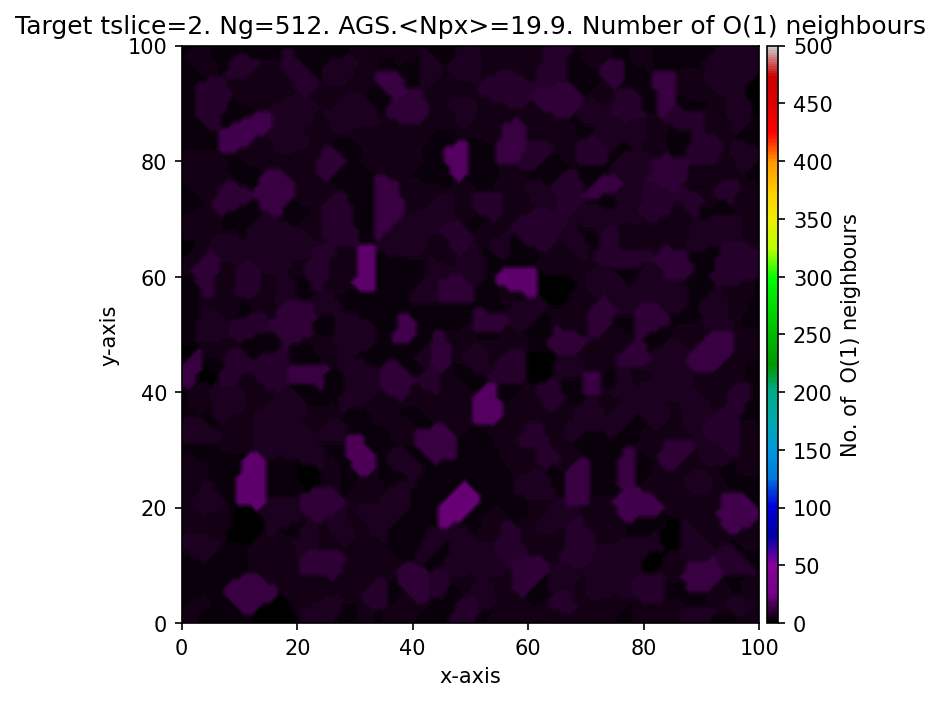

In [13]:
"""
Plot the number of O(n) neighbours for target and sample at a given temporal
slice.
"""
PROCEED = True
# vmax_custom = tgt_nneigh_field_grid.max()
if PROCEED:
    GS_name = 'Target'  # Options: Target, Sample
    # --------------------------
    vmax_custom = 500
    cbar_tick_incr = 50
    # --------------------------
    if GS_name in ('target', 'Target'):
        temporal_slice = tgt_slice
        num_of_grains = tgt.gs[tgt_slice].n
        nneigh_field_grid = tgt_nneigh_field_grid
        mgs = np.round(tgt_npixels_mean, 1)
    elif GS_name in ('sample', 'Sample'):
        temporal_slice = smp_slice
        num_of_grains = smp.gs[smp_slice].n
        nneigh_field_grid = smp_nneigh_field_grid
        mgs = np.round(smp_npixels_mean, 1)
    # --------------------------
    title_mgs = mgs
    # --------------------------
    plt.figure(figsize=(6, 5), dpi=150)
    levels = np.arange(0, vmax_custom+2, 2)
    contour = plt.contourf(nneigh_field_grid,
                           levels=levels, vmin=0, vmax=vmax_custom,
                           cmap='nipy_spectral')
    # plt.scatter(tgt_grain_centroids[:,0], tgt_grain_centroids[:,1], s=1, color='black')
    plt.xlabel('x-axis'), plt.ylabel('y-axis')

    plt.title(f'{GS_name} tslice={temporal_slice}. Ng={num_of_grains}. AGS.<Npx>={title_mgs}. Number of O({neigh_order}) neighbours', fontsize=12)
    axs = plt.gca()
    # create an axes on the right side of ax. The width of cax will be 5%
    # of ax and the padding between cax and ax will be fixed at 0.05 inch.
    # REF: https://stackoverflow.com/questions/18195758/set-matplotlib-colorbar-size-to-match-graph
    divider = make_axes_locatable(axs)
    cax = divider.append_axes("right", size="2%", pad=0.05)
    # plt.colorbar(contour, format=ticker.FormatStrFormatter('%.0f'), location='right')
    cbar = plt.colorbar(contour, format=ticker.FormatStrFormatter('%.0f'),
                        cax=cax, ticks=range(0, vmax_custom+cbar_tick_incr, cbar_tick_incr),
                        label=f'No. of  O({neigh_order}) neighbours')
    cbar.ax.tick_params(labelsize=10)
    axs.set_aspect('equal', 'box')

Sample. Working on neighbour order: 1
Sample. Working on neighbour order: 2
Sample. Working on neighbour order: 3
Sample. Working on neighbour order: 4
Sample. Working on neighbour order: 5
Sample. Working on neighbour order: 6
Sample. Working on neighbour order: 7
Sample. Working on neighbour order: 8
Sample. Working on neighbour order: 9
----------------------------------------
Sample. tslice: 1. Working on neighbour order: 1

 -------------------------
NOTE:  
 	 This gs tslice has'nt been characterised.
NOTE:  
 	 Charecterising to proceed.
Extracting requested GS props across all available states
--------State value: 5 of 10
--------State value: 10 of 10
----------------------------------------
NOTE:  
 	 this gs tslice has now been charactised.
NOTE:  
 	 Proceeding with neighbourhood gid calculations.

 -------------------------
Extracting neigh list for grain: 100
Extracting neigh list for grain: 200
Extracting neigh list for grain: 300
Extracting neigh list for grain: 400
Extr

C:\Users\rg5749\AppData\Local\Temp\ipykernel_13428\1056575119.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  snsbph.set_yticklabels(snsbph.get_yticklabels(), fontsize=12)


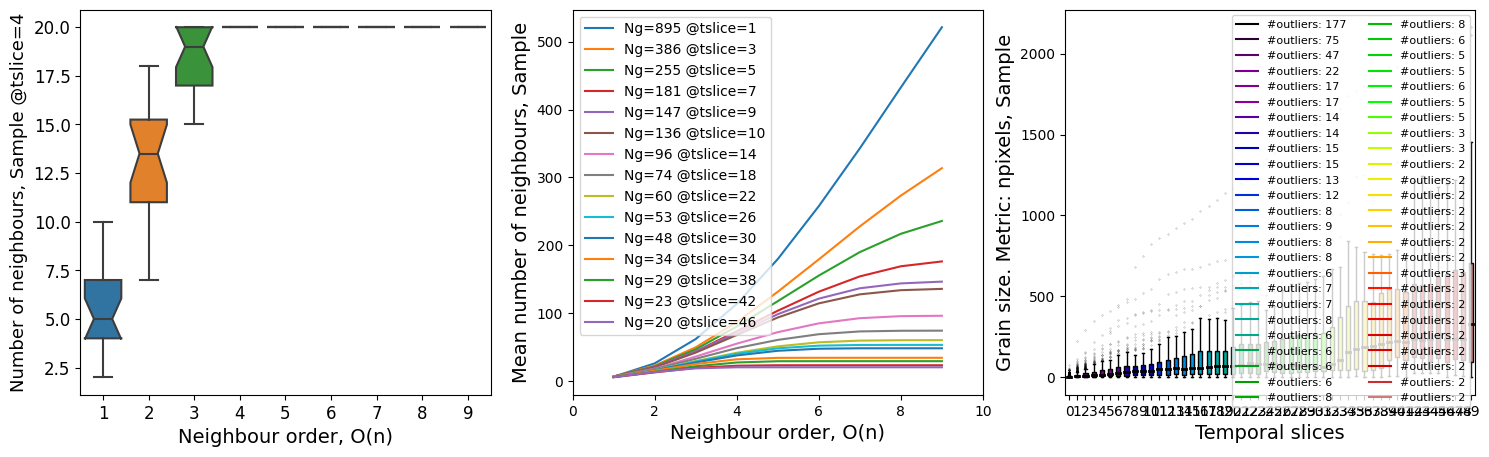

In [14]:
"""
Carry out O(n) sensitivity on the nneigh statistics.
"""
DO_THIS_STUDY = True

if DO_THIS_STUDY:
    GS_name = 'Sample'
    neighbour_orders = np.arange(1, 10, 1)

    if GS_name in ('target', 'Target'):
        time_slice = tgt_slice
        GSTR = tgt.gs
    elif GS_name in ('sample', 'Sample'):
        time_slice = smp_slice
        GSTR = smp.gs

    GSTR_tslice = GSTR[time_slice]

    nneigh_no = {}

    for no in neighbour_orders:
        print(f'{GS_name}. Working on neighbour order: {no}')
        gstr_nneighgids = GSTR_tslice.get_upto_nth_order_neighbors_all_grains(no, include_parent=True,
                                                                      output_type='list')
        gstr_nneigh_field = np.array([len(gstr_nneighgids[gid]) for gid in GSTR_tslice.gid])

        nneigh_no[no] = list(gstr_nneigh_field)
    nneigh_no = pd.DataFrame(nneigh_no)

    tslices = np.array(list(GSTR.keys()))
    tslices = np.hstack((tslices[1:10:2], tslices[10::4]))
    neighbour_orders = np.arange(1, 10, 1)
    mean_nneigh_no_all_tslices = {}
    for tslice in tslices:
        GSTR_tslice = GSTR[tslice]
        nneigh_no = {}
        print(40*'-')
        for no in neighbour_orders:
            print(f'{GS_name}. tslice: {tslice}. Working on neighbour order: {no}')
            gstr_nneighgids = GSTR_tslice.get_upto_nth_order_neighbors_all_grains(no, include_parent=True,
                                                                          output_type='list')
            gstr_nneigh_field = np.array([len(gstr_nneighgids[gid]) for gid in GSTR_tslice.gid])
            nneigh_no[no] = list(gstr_nneigh_field)
        nneigh_no = pd.DataFrame(nneigh_no)
        mean_nneigh_no_all_tslices[tslice] = nneigh_no.mean()

    grain_areas_all_tslices = {}
    for tslice in list(GSTR.keys()):
        print(f'{GS_name}. Extracting grain pixel areas @tslice={tslice}')
        grain_areas_all_tslices[tslice] = GSTR[tslice].find_grain_size_fast(metric='npixels')

    fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    snsbph = sns.boxplot(nneigh_no, notch=True, ax=ax[0])
    snsbph.set_xlabel('Neighbour order, O(n)', fontsize=14)
    snsbph.set_ylabel(f'Number of neighbours, {GS_name} @tslice={time_slice}', fontsize=13)
    snsbph.set_xticklabels(snsbph.get_xticklabels(), fontsize=12)
    snsbph.set_yticklabels(snsbph.get_yticklabels(), fontsize=12)

    for tslice, nneigh_no_tslice in zip(tslices, mean_nneigh_no_all_tslices.values()):
        ax[1].plot(neighbour_orders, nneigh_no_tslice, label=f'Ng={GSTR[tslice].n} @tslice={tslice}')
    ax[1].legend()
    ax[1].set_xlabel('Neighbour order, O(n)', fontsize=14)
    ax[1].set_ylabel(f'Mean number of neighbours, {GS_name}', fontsize=14)
    ax[1].set_xlim([0, neighbour_orders.max()+1])

    data = list(grain_areas_all_tslices.values())
    keys = grain_areas_all_tslices.keys()
    colormap = cm.get_cmap('nipy_spectral')
    COLORS = [colormap(i / len(keys)) for i in range(len(keys))]

    mplboxh = ax[2].boxplot(data, patch_artist=True)
    for patch, color in zip(mplboxh['boxes'], COLORS):
        patch.set_facecolor(color)
    NOutliers = []
    for key, _data_, color in zip(keys, data, COLORS):
        ax[2].plot([], [], color=color, label=f'#outliers: {len(find_outliers_iqr(_data_))}')
    ax[2].set_xticks(ticks=np.arange(1, len(keys) + 1), labels=keys)
    for flier in mplboxh['fliers']:
        flier.set(marker='.', color='red', alpha=0.5, markersize=0.5)
    for median in mplboxh['medians']:
        median.set(color='black', linewidth=2)
    ax[2].set_xlabel('Temporal slices', fontsize=14)
    ax[2].set_ylabel(f'Grain size. Metric: npixels, {GS_name}', fontsize=14)
    ax[2].legend(fontsize=8, ncol=2)